# SVM Evaluation & Predictions

This notebook loads the trained **SVM** pipeline for pneumonia detection (normal / bacteria / virus),
rebuilds the DataLoaders via `prepocessing.ipynb`, then computes metrics on the **test set** and shows a few predictions.

We use the same tools as in training:
- **scikit-learn** for the SVM classifier, PCA, and evaluation metrics,
- **grayscale conversion + flattening** to extract features from image tensors,
- the saved pipeline (scaler + PCA + SVM) from `01_train_svm.ipynb`.

The goal is to compute several classification metrics (Accuracy, Precision, Recall, F1-score, ROC-AUC) and visualize them as a **bar chart**.

c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images


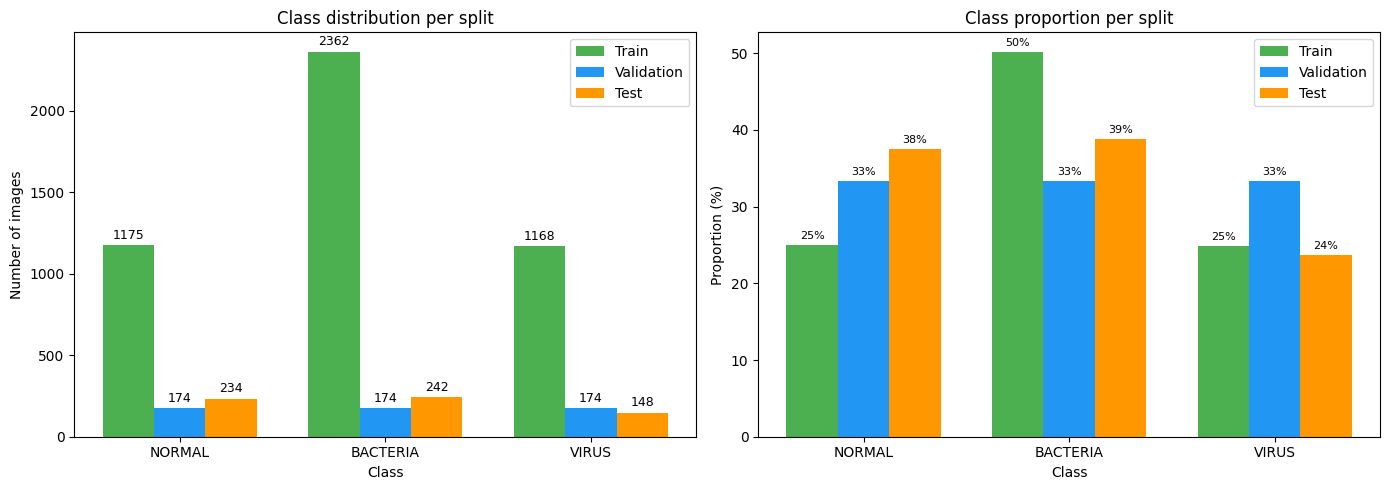


Summary:
Split          NORMAL   BACTERIA    VIRUS    Total
--------------------------------------------------
Train            1175       2362     1168     4705
Validation        174        174      174      522
Test              234        242      148      624

 Transforms applied!
 Images will be augmented on-the-fly when you load them


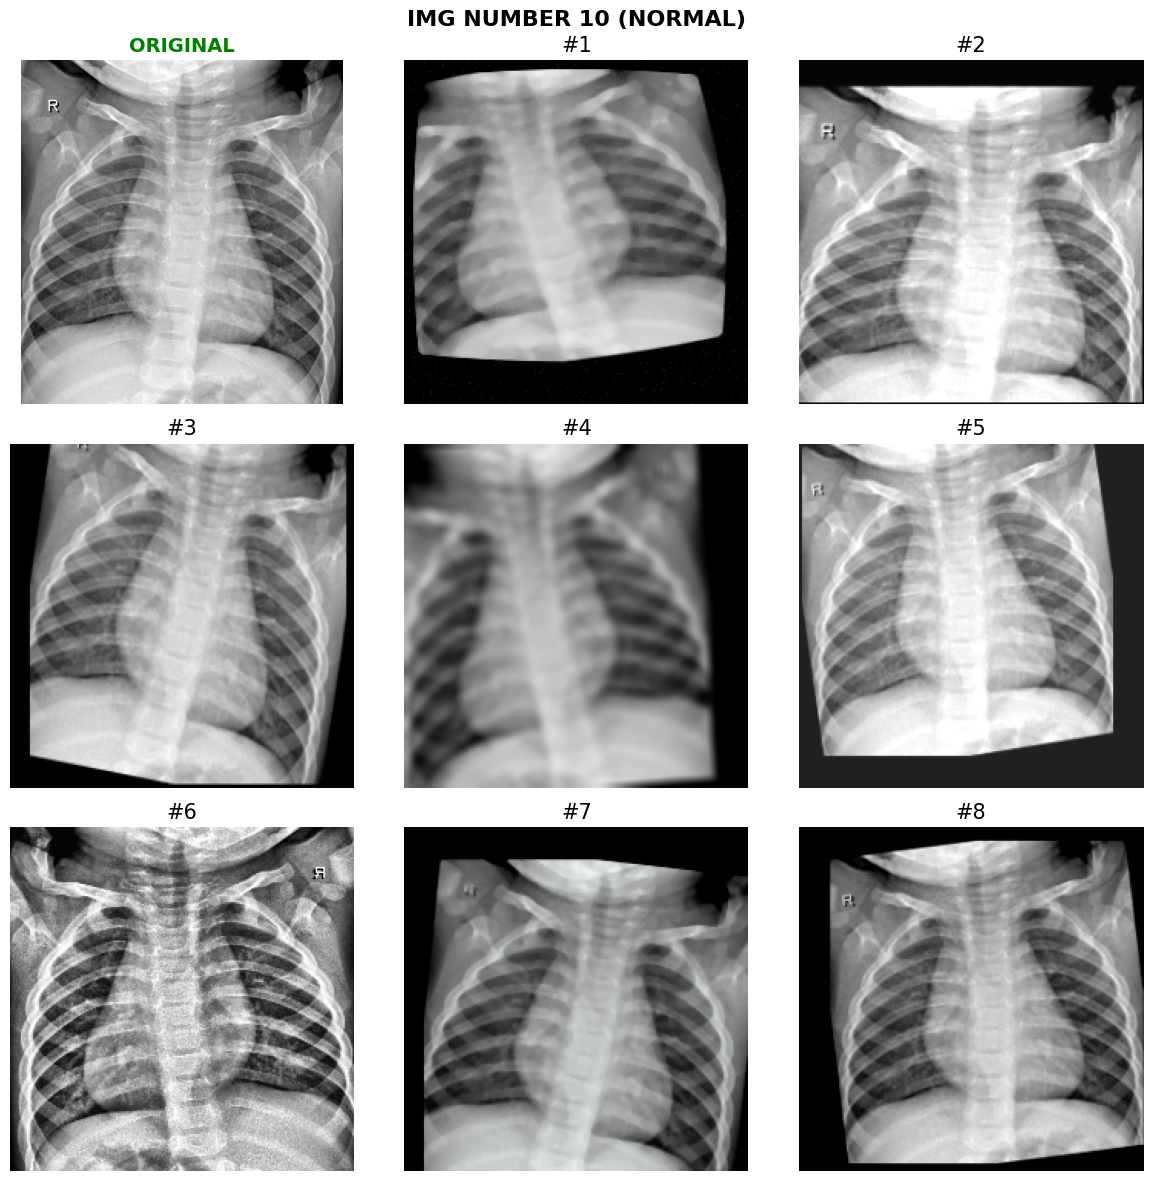


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 1, 0, 1, 2, 1, 1, 1, 2, 2]
Label distribution: [9, 14, 9]


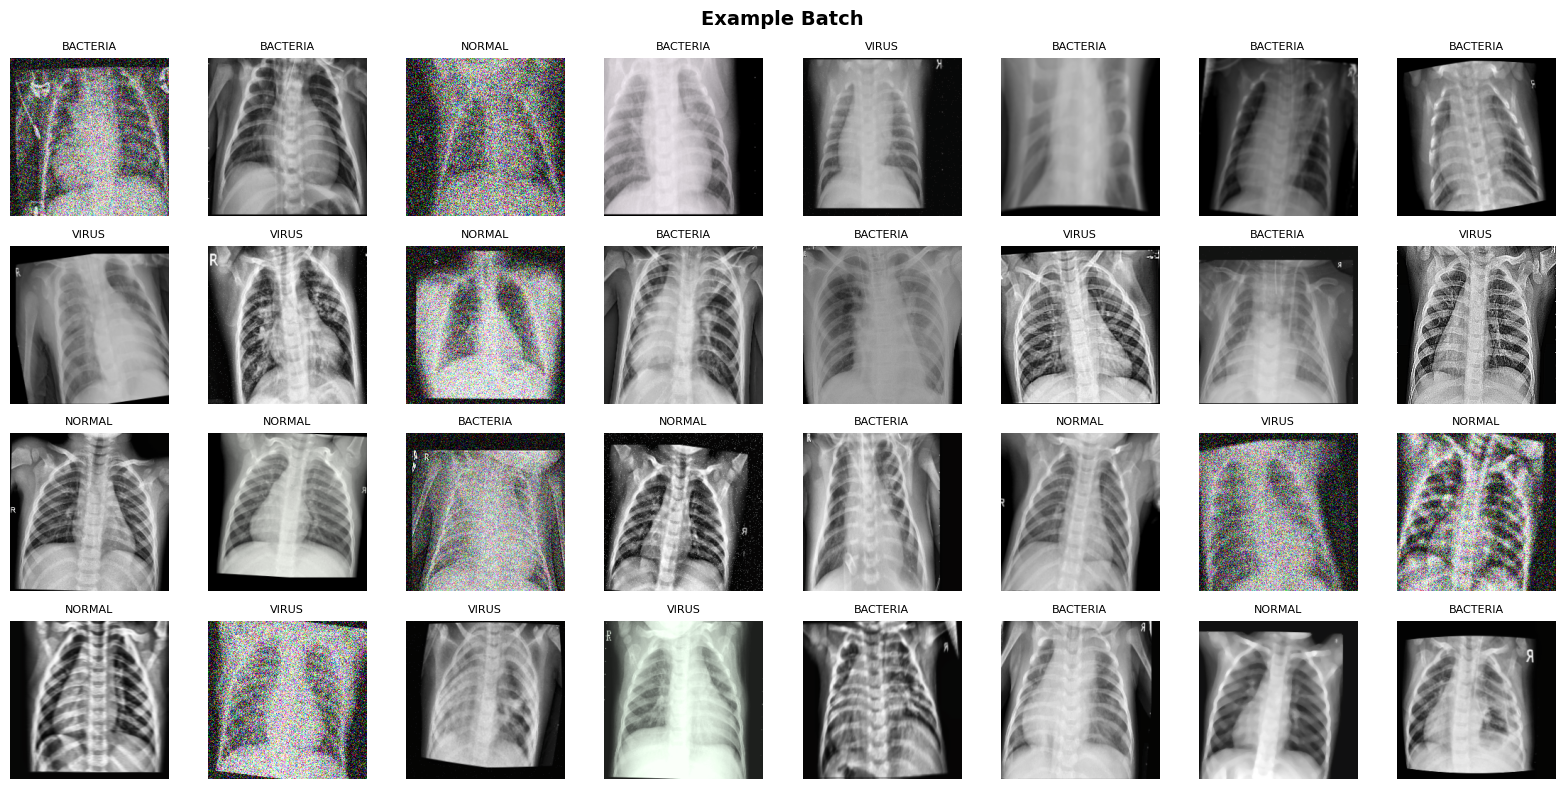

In [1]:
# Reload the augmentation pipeline and DataLoaders
# This runs the preprocessing notebook to recreate test_loader
%run "../prepocessing.ipynb"

## 1. Loading the pipeline and extracting test features

We reload the saved pipeline (scaler + PCA + SVM) and extract features from the test set using the same preprocessing steps as during training.

In [2]:
import numpy as np
import joblib
from tqdm.auto import tqdm

# ImageNet normalization constants
MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
STD = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

class_names = ["normal", "bacteria", "virus"]

def extract_features(loader, desc="Extracting"):
    """Extract grayscale flattened features and labels from a DataLoader."""
    all_features = []
    all_labels = []

    for batch in tqdm(loader, desc=desc):
        images = batch["image"].numpy()
        labels = batch["label"].numpy()

        # Denormalize
        images = images * STD + MEAN
        images = np.clip(images, 0, 1)

        # Convert to grayscale
        gray = 0.2989 * images[:, 0] + 0.5870 * images[:, 1] + 0.1140 * images[:, 2]

        # Flatten
        flat = gray.reshape(gray.shape[0], -1)

        all_features.append(flat)
        all_labels.append(labels)

    return np.concatenate(all_features), np.concatenate(all_labels)

# Load saved pipeline
pipeline = joblib.load("./svm_pneumonia.joblib")
scaler = pipeline["scaler"]
pca = pipeline["pca"]
svm = pipeline["svm"]
print(f"Pipeline loaded (PCA components: {pca.n_components_})")

# Extract test features
X_test, y_test = extract_features(test_loader, desc="Test")

# Apply same preprocessing
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nX_test_pca shape: {X_test_pca.shape}")
print(f"y_test shape:     {y_test.shape}")

Pipeline loaded (PCA components: 900)


Test: 100%|██████████| 20/20 [00:08<00:00,  2.35it/s]



X_test_pca shape: (624, 900)
y_test shape:     (624,)


Classification report (per class):
              precision    recall  f1-score   support

      normal       0.89      0.48      0.63       234
    bacteria       0.69      0.91      0.79       242
       virus       0.47      0.57      0.52       148

    accuracy                           0.67       624
   macro avg       0.69      0.66      0.65       624
weighted avg       0.72      0.67      0.66       624


Global metrics (macro-average):
Accuracy  : 0.6715
Precision : 0.6865
Recall    : 0.6568
F1-score  : 0.6451
ROC-AUC   : 0.8778


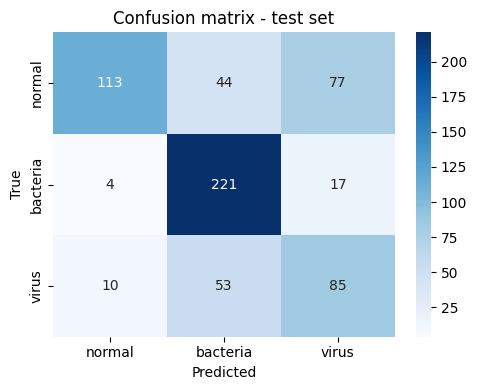

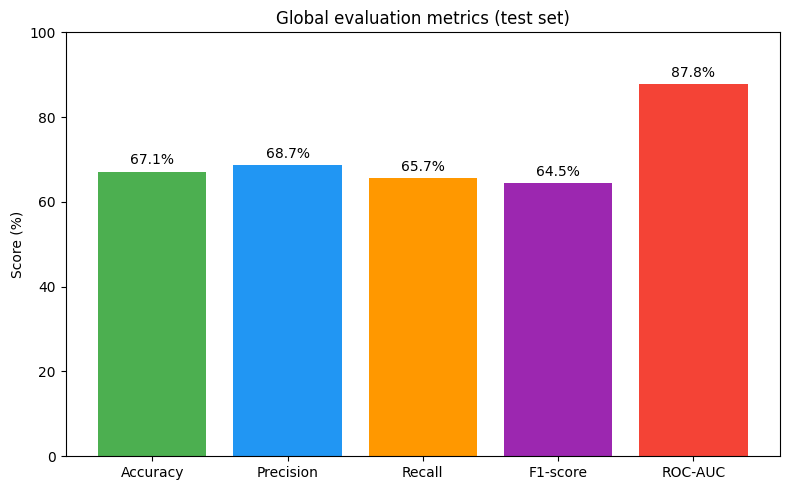

In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions and probabilities
all_preds = svm.predict(X_test_pca)
all_probs = svm.predict_proba(X_test_pca)

# Global metrics (macro-average for per-class balancing)
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds, average="macro", zero_division=0)
recall = recall_score(y_test, all_preds, average="macro", zero_division=0)
f1 = f1_score(y_test, all_preds, average="macro", zero_division=0)

# Multiclass ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(y_test, all_probs, multi_class="ovr")
except ValueError:
    roc_auc = float("nan")

print("Classification report (per class):")
print(classification_report(y_test, all_preds, target_names=class_names))

print("\nGlobal metrics (macro-average):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

# Bar chart of metrics (percentage)
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
metrics_values = [accuracy, precision, recall, f1, roc_auc]
metrics_percent = [m * 100 for m in metrics_values]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_percent, color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0", "#f44336"])
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.title("Global evaluation metrics (test set)")
for i, v in enumerate(metrics_percent):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Qualitative visualization of a few predictions

To complement the global metrics, we display a few test-set images with:

- the **true label**,
- the **model prediction**.

This makes it easier to visually inspect the model behavior on concrete examples (including potential mistakes).

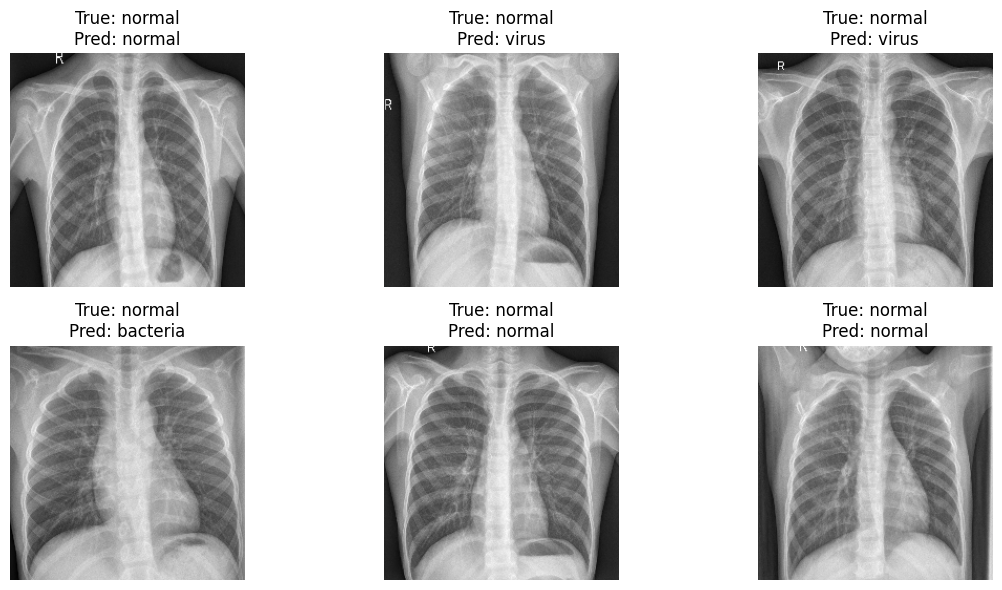

In [8]:
# Visualize a few predictions

num_examples = 6
shown = 0
idx = 0  # global index into the test set

plt.figure(figsize=(12, 6))

for batch in test_loader:
    images = batch["image"].numpy()  # (B, 3, 224, 224)
    labels = batch["label"].numpy()

    for i in range(images.shape[0]):
        if shown >= num_examples:
            break

        # Denormalize for display
        img = images[i] * np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1) \
              + np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        img = np.clip(img.transpose(1, 2, 0), 0, 1)

        true_label = class_names[labels[i]]
        pred_label = class_names[all_preds[idx]]

        plt.subplot(2, 3, shown + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"True: {true_label}\nPred: {pred_label}")

        shown += 1
        idx += 1

    if shown >= num_examples:
        break

plt.tight_layout()
plt.show()